##  read SQL from file:

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect("../data/credit_risk.db")

with open("../sql/01_schema.sql", "r") as f:
    print(f.read())

-- total row counts
SELECT 'transactions' as table_name, COUNT(*) as total_rows FROM transactions
UNION ALL
SELECT 'creditcard', COUNT(*) FROM creditcard;

-- fraud vs legit split - transactions table
SELECT CASE is_fraud WHEN 1 THEN 'Fraud' ELSE 'Legit' END AS label,
COUNT(*) AS total,
ROUND(COUNT(*)*100.0/(SELECT COUNT(*) FROM transactions), 3) AS pct
FROM transactions
GROUP BY is_fraud;

-- fraud vs legit split - creditcard table
SELECT CASE Class WHEN 1 THEN 'Fraud' ELSE 'Legit' END AS label,
COUNT (*) AS total,
ROUND(COUNT(*)*100.0/(SELECT COUNT(*) FROM creditcard),3) AS pct
FROM creditcard
GROUP BY Class;

-- unique merchant categories
SELECT DISTINCT category FROM transactions ORDER BY category;

-- Transaction amount stats by fraud label
SELECT
CASE is_fraud WHEN 1 THEN 'Fraud' ELSE 'Legit' END AS label,
ROUND(MIN(amt), 2) AS min_amt,
ROUND(MAX(amt), 2) AS max_amt,
ROUND(AVG(amt), 2) AS avg_amt
FROM transactions
GROUP BY is_fraud;


##  class imbalance chart:

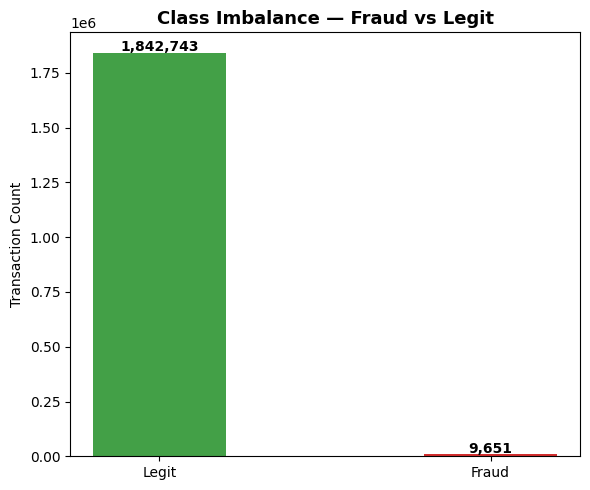

In [2]:
df_class = pd.read_sql_query("""
    SELECT CASE is_fraud WHEN 1 THEN 'Fraud' ELSE 'Legit' END AS label,
           COUNT(*) AS total FROM transactions GROUP BY is_fraud
""", conn)

fig, ax = plt.subplots(figsize=(6,5))
colors = ['#43a047','#d32f2f']
ax.bar(df_class['label'], df_class['total'], color=colors, width=0.4)
ax.set_title('Class Imbalance — Fraud vs Legit', fontsize=13, fontweight='bold')
ax.set_ylabel('Transaction Count')
for i, val in enumerate(df_class['total']):
    ax.text(i, val + 5000, f"{val:,}", ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/01_class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

## amount distribution:

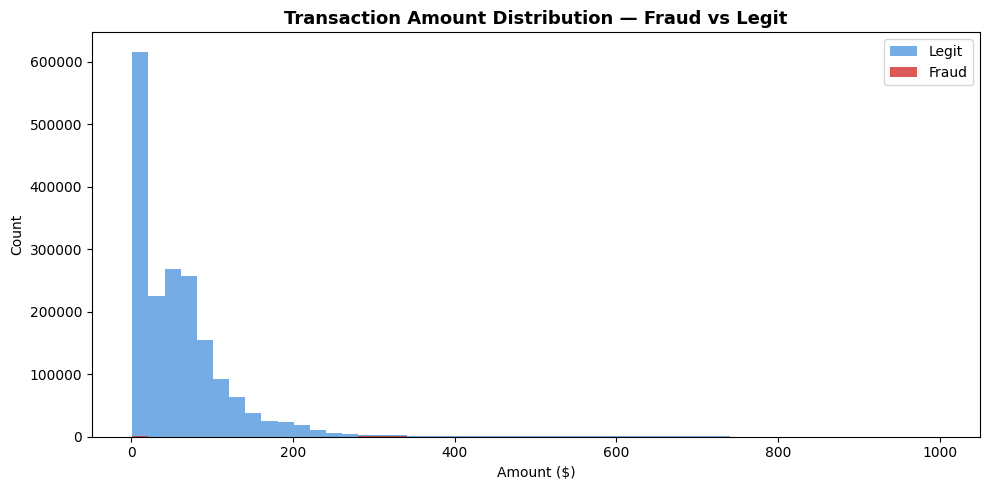

In [3]:
df_amounts = pd.read_sql_query("""
    SELECT amt, is_fraud FROM transactions WHERE amt < 1000
""", conn)

fig, ax = plt.subplots(figsize=(10,5))
ax.hist(df_amounts[df_amounts['is_fraud']==0]['amt'], 
        bins=50, alpha=0.6, color='#1976d2', label='Legit')
ax.hist(df_amounts[df_amounts['is_fraud']==1]['amt'], 
        bins=50, alpha=0.8, color='#d32f2f', label='Fraud')
ax.set_title('Transaction Amount Distribution — Fraud vs Legit', fontsize=13, fontweight='bold')
ax.set_xlabel('Amount ($)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/01_amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

conn.close()